(b)

<Axes: >

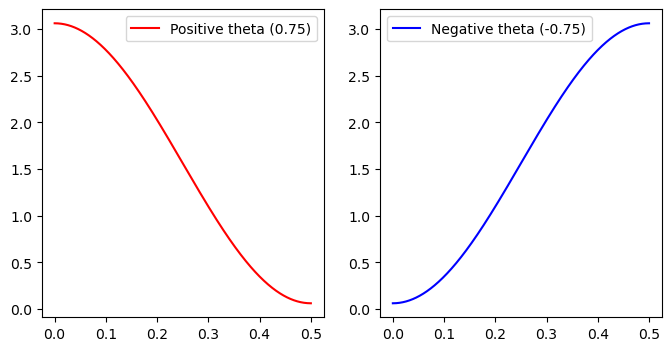

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#plot just (0, 0.5) since cos is even function
omega = np.linspace(0, 0.5, 1000)
postheta, negtheta = 0.75, -0.75
psdPos = (1 + 2*postheta*np.cos(2*np.pi*omega) + postheta**2)
psdNeg = (1 + 2*negtheta*np.cos(2*np.pi*omega) + negtheta**2)
fig, axes = plt.subplots(1,2, figsize=(8,4))
sns.lineplot(x=omega, y=psdPos, label="Positive theta (0.75)", ax = axes[0], color = "red")
sns.lineplot(x=omega, y=psdNeg, label="Negative theta (-0.75)", ax = axes[1], color = "blue")

(c)
The spectra can be interpreted as two different kinds of filters based on the theta value. When theta is positive, the spectra shows us that the MA(1) model is a low pass filter, meaning shocks have positive momentum/trend. When theta is negative, the spectra reveals that the MA(1) model is a high pass filter, meaning it blocks low frequencies but allows high frequencies to pass, leading to a jagged, mean-reverting model.

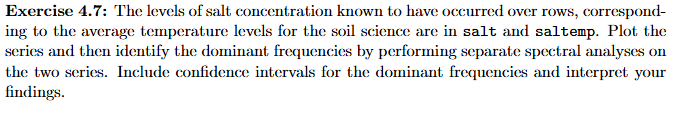

<Axes: ylabel='Value'>

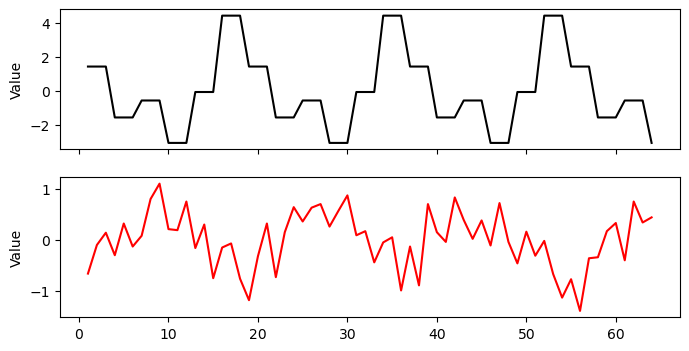

In [2]:
import pandas as pd
import statsmodels.api as sm
from scipy import signal
df1 = pd.read_csv("salt.csv")
df2 = pd.read_csv("saltemp.csv")
df1['Value'] = df1['Value'] - np.mean(df1['Value'])
df2['Value'] = df2['Value'] - np.mean(df2['Value'])                                      
fig, axes = plt.subplots(2,1, figsize=(8,4), sharex=True)
xindex = np.arange(1, len(df1)+1, 1)
sns.lineplot(x = xindex, y = df1['Value'], ax=axes[0], color = 'black')
sns.lineplot(x = xindex, y = df2['Value'], ax=axes[1], color = 'red')

Salt 95% CI Bounds   : [8.64, 27.72] rows
Temp 95% CI Bounds   : [8.97, 28.08] rows


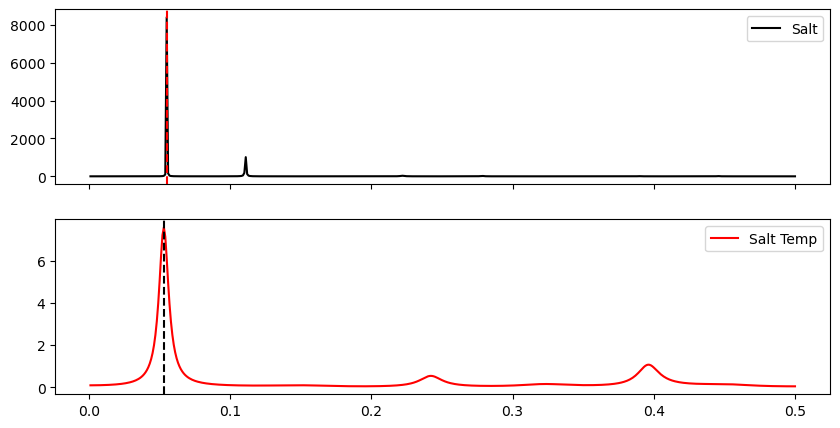

In [3]:
from statsmodels.tsa.ar_model import AutoReg
bestAIC = np.inf
bestModel = None
Ys = [df1['Value'], df2['Value']]
phis = []
sigmas = []
orders = []
for y in Ys:
    for lag in range(1, 15):
        model = AutoReg(y, lags = lag, trend='n').fit()
        if model.aic < bestAIC:
            bestModel = model
    bestAIC = np.inf
    phis.append(bestModel.params)
    sigmas.append(bestModel.sigma2)
    orders.append(len(bestModel.params))

saltParams = [phis[0], sigmas[0], orders[0]]
salTempParams = [phis[1], sigmas[1], orders[1]]
freqs = np.linspace(0.001, 0.5, 500)
params = [saltParams, salTempParams]
specs = []
for model in params:
    p = len(model[0])
    spec = np.zeros(500)
    for i, w in enumerate(freqs):
        k = np.arange(1, p+1)
        transferFunc = 1 - np.sum(model[0] * np.exp(-2j * np.pi * w * k))
        spec[i] = model[1] / (np.abs(transferFunc) ** 2)
    specs.append(spec.copy())
    
idxSalt = np.argmax(specs[0])
domFreqSalt = freqs[idxSalt]
saltPeriod = 1/domFreqSalt
idxSalTemp = np.argmax(specs[1])
domFreqSaltTemp = freqs[idxSalTemp]
salTempPeriod = 1/domFreqSaltTemp

from scipy.stats import chi2
N = len(df1['Value'])
p = len(saltParams[0])
v = (2 * N)/p
chiLow, chiHigh = chi2.ppf(0.025, df=v), chi2.ppf(0.975, df=v)
fErrSaltPeriod = saltPeriod * (1-(v/chiHigh))
saltPeriodLower, saltPeriodHigher = saltPeriod - fErrSaltPeriod, saltPeriod + fErrSaltPeriod
print(f"Salt 95% CI Bounds   : [{saltPeriodLower:.2f}, {saltPeriodHigher:.2f}] rows")
N = len(df2['Value'])
p = len(salTempParams[0])
v = (2 * N)/p
chiLow, chiHigh = chi2.ppf(0.025, df=v), chi2.ppf(0.975, df=v)
fErrSaltTempPeriod = salTempPeriod * (1-(v/chiHigh))
saltPeriodTempLower, saltPeriodTempHigher = salTempPeriod - fErrSaltTempPeriod, saltPeriod + fErrSaltTempPeriod
print(f"Temp 95% CI Bounds   : [{saltPeriodTempLower:.2f}, {saltPeriodTempHigher:.2f}] rows")
fig, axes = plt.subplots(2,1, figsize=(10,5), sharex=True)
sns.lineplot(x=freqs, y=specs[0], ax = axes[0], label="Salt", color='Black')
axes[0].axvline(x=domFreqSalt, color='red', linestyle='--', label=f'Peak: {domFreqSalt:.4f}')
sns.lineplot(x=freqs, y=specs[1], ax = axes[1], label="Salt Temp", color='Red')
axes[1].axvline(x=domFreqSaltTemp, color='black', linestyle='--', label=f'Peak: {domFreqSalt:.4f}')

The Spectra show that both salt concentration and soil temperature have a dominant frequency at omega = 0.0625 which corresponds to every 16 rows. While salt concentration is heavily influenced by this frequency and little else, the sooil temperature seems to have some secondary and tertiary influences in the series. The 95% CI for Salt concentration is [8.64, 27.72] and [8.97, 28.08] for soil temperature, this uncertainty could be due to the AR(P) model or limited data.

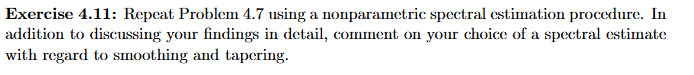

In [4]:
df1 = pd.read_csv("salt.csv")
df2 = pd.read_csv("saltemp.csv")
df1['Value'] = df1['Value'] - np.mean(df1['Value'])
df2['Value'] = df2['Value'] - np.mean(df2['Value'])    
Ys = [df1['Value'], df2['Value']]
Labels = ["salt.csv", "saltemp.csv"]
frequency = []
psds = []
for y in Ys:
    frequencies, psd = signal.welch(y, fs=1.0, nperseg=min(len(y), 256))
    frequency.append(frequencies)
    psds.append(psd)

for i, set in enumerate(Ys):
    freqs = frequency[i]
    power = psds[i]
    peakIdx = np.argmax(power[1:])+1
    peakFreq = freqs[peakIdx]
    totalPower = np.trapezoid(power,freqs)   
    dominantPeriod = 1.0 / peakFreq if peakFreq != 0 else np.nan
    print(f"{Labels[i]}")
    print(f"Dominant Frequency: {peakFreq}")
    print(f"Dominant Period: {dominantPeriod}")
    print(f"Total Variance: {totalPower}\n")

salt.csv
Dominant Frequency: 0.0625
Dominant Period: 16.0
Total Variance: 5.62801461006794

saltemp.csv
Dominant Frequency: 0.0625
Dominant Period: 16.0
Total Variance: 0.28441678949336546



The non-parametric estimate gives us an identical dominant frequency and dominant period as the parametric estimate. The non-parametric method used, Welch's periodogram, averages overlapping signals which serves to smooth out noise. Further, a window function is used on the time-indexed data to prevenet weak signals from being convoluted with strong signals. Welch's is an ideal choice for limited, finite data and is great for limiting the influence of the edges of the data set.

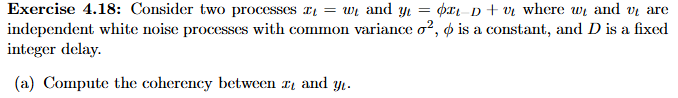
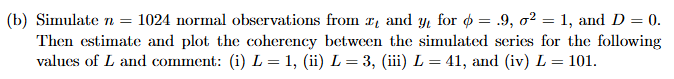

(a)
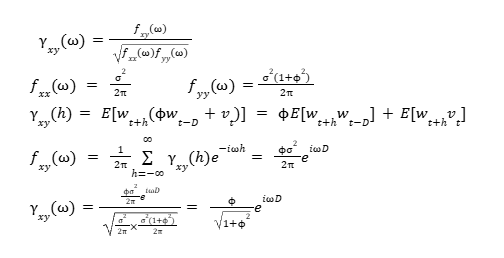

(b)

Theoretical coherance: 0.44751381215469616


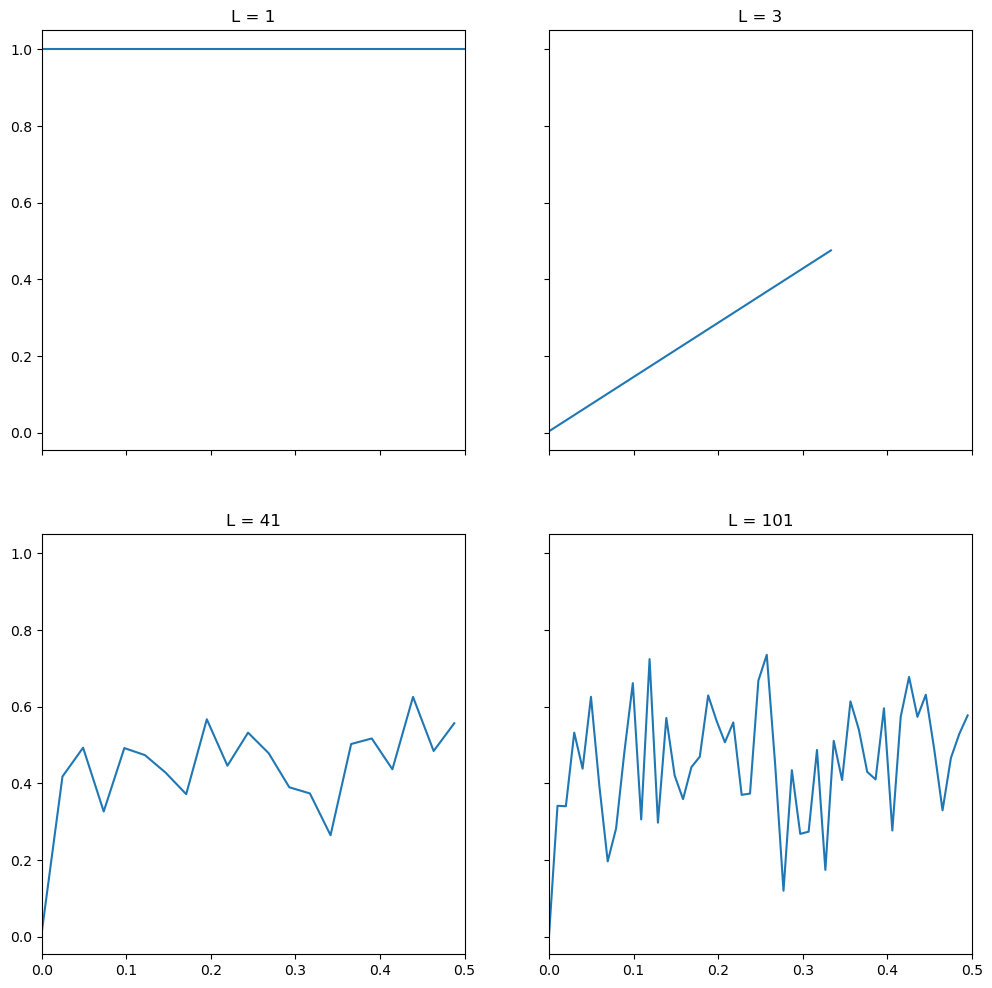

In [5]:
n = 1024
phi = 0.9
sigma2 = 1
D = 0
Ls = [1, 3, 41, 101]
xt = np.random.normal(0, np.sqrt(sigma2), n)
vt = np.random.normal(0, np.sqrt(sigma2), n)
xtd = phi * np.roll(xt, D) + vt
theoreticalCoherance = (phi**2) / (phi**2 + 1)
fig, axes = plt.subplots(2,2, figsize=(12,12), sharex=True, sharey=True)
axes = axes.flatten()
for i, L in enumerate(Ls):
    ax=axes[i]
    if L == 1:
        freqs = np.linspace(0, 0.5, n//2+1)
        co = np.ones_like(freqs)
    else: 
        freqs, co = signal.coherence(xt, xtd, fs=1.0, window='boxcar', nperseg=L)
    ax.set_xlim(0, 0.5)
    ax.plot(freqs, co)
    ax.set_title(f"L = {L}")
print(f"Theoretical coherance: {theoreticalCoherance}")

As L increases, the plots get closer to being centered around the true theoretical coherance of .4475. At L = 1 and L = 3, the smoothing is so biased that they are effectively useless. At L = 41 and L = 101, the plots experience more noise but around the actual true theoretical value.

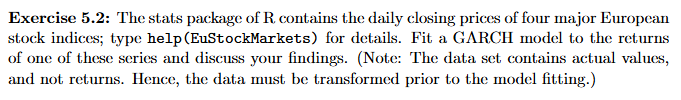

In [6]:
from arch import arch_model
dataset = sm.datasets.get_rdataset("EuStockMarkets", "datasets")
df = pd.DataFrame(dataset.data)
FTSEprices = df['FTSE']
FTSEreturns = 100 * np.log(FTSEprices / FTSEprices.shift(1)).dropna()
model = arch_model(FTSEreturns, mean="Constant", vol="GARCH", p=1, q=1)
model_fit = model.fit(disp="off")
print(model_fit.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                   FTSE   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2134.82
Distribution:                  Normal   AIC:                           4277.64
Method:            Maximum Likelihood   BIC:                           4299.75
                                        No. Observations:                 1859
Date:                Thu, Jul 30 2026   Df Residuals:                     1858
Time:                        13:00:51   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0491  1.702e-02      2.885  3.909e-03 [1.

What we find from the GARCH output is that the beta[1] term is extremely significant and shows that the next-day volatility is reliant on the current-day volatility. Summing the alpha[1] and beta[1], or ARCH and GARCH parameters gives us .987, meaning volatility has long memory and shocks do not decay quickly. However, despite being close to 1, the sum is still less than 1, meaning the model is stationary and will eventually experience mean-reversion.

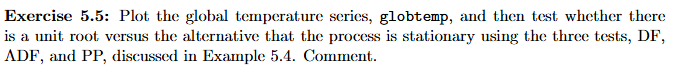

DF Test result and P value:
-2.470379785532344 0.1228485645728849
ADF Test result and P value:
2.676589906146484 0.9990854239724867
PP Test result and P value:
-2.0277929513941757 0.2745213593395851


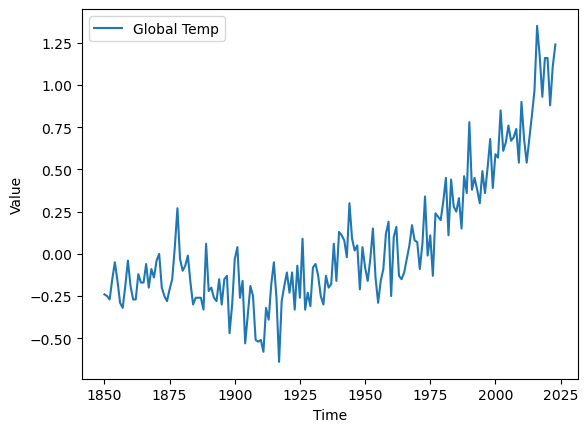

In [7]:
from statsmodels.tsa.stattools import adfuller
from arch.unitroot import PhillipsPerron
df = pd.read_csv("gtemp_both.csv")
globtemp = df['Value']
tIdx = df['Time']
sns.lineplot(x=tIdx, y=globtemp, label="Global Temp")
#unit root tests
dftest = adfuller(globtemp, maxlag = 0, regression="c")
print("DF Test result and P value:")
print(dftest[0], dftest[1])
adftest = adfuller(globtemp, autolag="AIC", regression="c")
print("ADF Test result and P value:")
print(adftest[0], adftest[1])
print("PP Test result and P value:")
pptest = PhillipsPerron(globtemp, trend="c")
print(pptest.stat, pptest.pvalue)

From the plot, it is clear that the trend is non-stationary. The three tests, DF, ADF, and PP confirm this as each returns a p-value far greater than our 0.05 significance level, proving that there is a unit root in this series driving the non-stationarity.